In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px  # interactive figures
import plotly.graph_objects as go
import seaborn as sns


In [2]:
import pandas as pd

df = pd.read_csv("../data_raw/date_24_art1_loreal.csv")

df.head()

,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_CU_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
0,01-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
1,02-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
2,03-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,770.0,574.75,0.0,0.0,72.25,278,267,0
3,04-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,770.0,574.75,0.0,0.0,72.29,267,376,0
4,05-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,700.0,522.50,0.0,0.0,65.72,376,366,0


standard deviation is a way to measure how "spread out" or "different" the values in a group are from the average.

If the standard deviation is small, it means most values are close to the average (not much variation).
If the standard deviation is large, it means the values are spread out and vary a lot from the average.

Conversie coloana data din object in datetime

In [3]:
df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")

C:\Users\Mara\AppData\Local\Temp\ipykernel_24680\2340964975.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATA                 734 non-null    datetime64[ns]
 1   ID_ARTICOL           734 non-null    int64         
 2   ARTICOL              734 non-null    object        
 3   CANTITATE            734 non-null    int64         
 4   VAL_IESIRE_FARA_TVA  734 non-null    float64       
 5   VAL_IESIRE_CU_TVA    734 non-null    float64       
 6   VAL_INTRARE_CU_TVA   734 non-null    float64       
 7   TOTAL_DISCOUNT       734 non-null    float64       
 8   RATA_DISCOUNT        703 non-null    float64       
 9   ADAOS                734 non-null    float64       
 10  STOC_INITIAL         734 non-null    int64         
 11  STOC_FINAL           734 non-null    int64         
 12  RUPTURA_STOC         734 non-null    int64         
dtypes: datetime64[ns](1), float64(6), i

In [5]:
# Sortare logică pentru time series
df = df.sort_values(by=["DATA"]).reset_index(drop=True)

In [6]:
# reguli de calitate
checks = {}

# 1) vânzare > 0 dar valoare = 0 (suspect)
checks["qty_pos_val_zero"] = df[(df["CANTITATE"] > 0) & (df["VAL_IESIRE_CU_TVA"] == 0)]

# 2) valoare > 0 dar cantitate = 0 (suspect)
checks["val_pos_qty_zero"] = df[(df["VAL_IESIRE_CU_TVA"] > 0) & (df["CANTITATE"] == 0)]

# 3) stoc final negativ (dacă există în dataset)
if "STOC_FINAL" in df.columns:
    checks["stoc_final_negativ"] = df[df["STOC_FINAL"] < 0]

# 4) discount > 0 dar rata_discount = 0 (suspect)
if "TOTAL_DISCOUNT" in df.columns and "RATA_DISCOUNT" in df.columns:
    checks["disc_pos_rata_zero"] = df[(df["TOTAL_DISCOUNT"] > 0) & (df["RATA_DISCOUNT"] == 0)]

# 5) 
checks["stockout_start"] = df[(df["STOC_INITIAL"] == 0) & (df["CANTITATE"] == 0)]
checks["no_sales_but_in_stock"] = df[(df["STOC_INITIAL"] > 0) & (df["CANTITATE"] == 0)]

{k: v.shape[0] for k, v in checks.items()}

{'qty_pos_val_zero': 0,
 'val_pos_qty_zero': 0,
 'stoc_final_negativ': 0,
 'disc_pos_rata_zero': 0,
 'stockout_start': 0,
 'no_sales_but_in_stock': 16}

In [7]:
cols = ["CANTITATE", "STOC_INITIAL", "STOC_FINAL", "VAL_IESIRE_FARA_TVA"]

(df[cols] < 0).sum()


CANTITATE              0
STOC_INITIAL           0
STOC_FINAL             0
VAL_IESIRE_FARA_TVA    0
dtype: int64

In [8]:
# df = df.set_index('DATA') 

In [9]:
# df

Pentru evitarea redundanței informaționale, variabilele puternic corelate vor fi filtrate.  ( gen val iesire cu fara tva, total discount - rata discount )

In [10]:
df_feat = df.drop(columns=[ "STOC_FINAL", "RUPTURA_STOC", "VAL_IESIRE_CU_TVA", "RATA_DISCOUNT"])

df_feat


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_CU_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,574.75,0.0,72.25,278
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,574.75,0.0,72.29,267
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,522.50,0.0,65.72,376
...,...,...,...,...,...,...,...,...,...
729,2025-12-30,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,12,719.02,627.00,0.0,92.02,1441
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,365.75,0.0,53.69,1429
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422


In [11]:

df_feat["DOW"] = df_feat["DATA"].dt.dayofweek          # 0..6
df_feat["ESTE_WEEKEND"] = (df_feat["DOW"] >= 5).astype(int)

# dacă ai deja LUNA ca yyyy-mm, păstreaz-o ca perioadă (opțional)
# df_feat["YYYY_MM"] = df_feat["DATA"].dt.to_period("M").astype(str)

# opțional: zi din lună (uneori surprinde patternuri de început/sfârșit)
df_feat["ZI_DIN_LUNA"] = df_feat["DATA"].dt.day

df_feat


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_CU_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL,DOW,ESTE_WEEKEND,ZI_DIN_LUNA
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,0,0,1
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,1,0,2
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,574.75,0.0,72.25,278,2,0,3
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,574.75,0.0,72.29,267,3,0,4
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,522.50,0.0,65.72,376,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
729,2025-12-30,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,12,719.02,627.00,0.0,92.02,1441,1,0,30
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,365.75,0.0,53.69,1429,2,0,31
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,3,0,1
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,4,0,2


In [12]:
fig = px.line(df, x='DATA', y='CANTITATE', title='Time Series with Range Slider and Selectors')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            # dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(width=1100, height=500)
fig.show()

## ARIMA

In [13]:
# df_art = df.set_index("DATA")["CANTITATE"].asfreq("D")
# ARIMA works with series, not dataframes
df_art = (
    df
    .set_index("DATA")["CANTITATE"]
    .astype(float)
    .sort_index()
)


In [14]:
df_art

DATA
2024-01-01     0.0
2024-01-02     0.0
2024-01-03    11.0
2024-01-04    11.0
2024-01-05    10.0
              ... 
2025-12-30    12.0
2025-12-31     7.0
2026-01-01     0.0
2026-01-02     0.0
2026-01-03    13.0
Name: CANTITATE, Length: 734, dtype: float64

In [15]:
df_art.map(type).value_counts().head(10)


CANTITATE
<class 'float'>    734
Name: count, dtype: int64

In [16]:
type(df_art)
df_art.name
df_art.index.name
df_art.dtype
df_art.head()


DATA
2024-01-01     0.0
2024-01-02     0.0
2024-01-03    11.0
2024-01-04    11.0
2024-01-05    10.0
Name: CANTITATE, dtype: float64

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning:

In the future `np.object` will be defined as the corresponding NumPy scalar.



In [18]:
# pip install tensorflow

In [19]:
forecast_horizon_daily = 30
n = len(df_art)
if forecast_horizon_daily >= n:
    raise ValueError("forecast_horizon_daily must be smaller than the series length")

split_idx = n - forecast_horizon_daily

split_idx


704

In [20]:
train = df_art.iloc[:split_idx]
test  = df_art.iloc[split_idx:]

In [21]:
# train.DATA.max(), test.DATA.min()

In [22]:
# import libraries
from statsmodels.tsa.stattools import adfuller

# ADF test
result = adfuller(train.dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# if p-value > 0.05, the series is non-stationary and needs differencing
if result[1] > 0.05:
    print("needs differencing")
else:
    print("time series is stationary")

ADF Statistic: -5.110318105758926
p-value: 1.336450064339246e-05
time series is stationary


In [23]:
from pmdarima import auto_arima

model_auto = auto_arima(
    train,
    seasonal=False,
    d=None,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

selected_order = model_auto.order
selected_order


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=4601.223, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=5877.932, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=4698.179, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=5363.880, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=4613.848, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=4602.397, Time=0.15 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=4606.219, Time=0.45 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=4589.761, Time=0.48 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=4589.908, Time=0.21 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=4575.340, Time=0.64 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=4585.418, Time=0.65 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=4586.451, Time=0.85 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=4584.504, Time=0.62 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=4630.755, Time=0.69 sec
 ARIMA(4,0,4)(0,0,0)[0]          

(3, 0, 3)

In [24]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train, order=selected_order)
arima_fit = arima.fit()


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [25]:
pred_arima = arima_fit.forecast(steps=forecast_horizon_daily)


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test, pred_arima)

mse = mean_squared_error(test, pred_arima)
rmse = np.sqrt(mse)

# mape = np.mean(np.abs((y_true - pred) / np.maximum(y_true, 1))) * 100

r2 = r2_score(test, pred_arima)


mae = float(mae)
rmse = float(rmse)


mae, mse, rmse,  r2

## fara r2



(3.9557565940887964, 26.1318892933244, 5.111935963343477, -0.41329850153187664)

In [27]:
import numpy as np

r = np.corrcoef(test, pred_arima)[0, 1]
float(r)
# arata daca modelul urmareste trandul, nu cat de exact prezice

-0.029428524244675344

In [28]:
import pandas as pd
import plotly.express as px

df_plot_arima = pd.DataFrame({
    "DATA": test.index,
    "Actual": test.values,
    "Predicted": pred_arima
})

df_long_arima = df_plot_arima.melt(
    id_vars="DATA",
    value_vars=["Actual", "Predicted"],
    var_name="Serie",
    value_name="Cantitate"
)

fig = px.line(
    df_long_arima,
    x="DATA",
    y="Cantitate",
    color="Serie",
    title="ARIMA – Actual vs Predicted"
)

fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Cantitate vândută",
    hovermode="x unified",
    legend_title_text=""
)

fig.update_xaxes(rangeslider_visible=True)

fig.show()



## ACF / PACF TEST

<Figure size 1000x400 with 0 Axes>

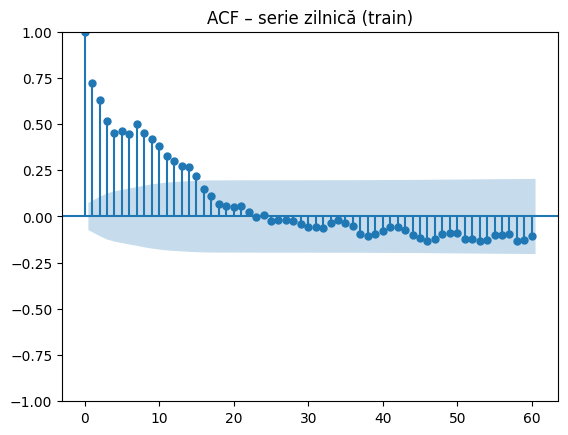

<Figure size 1000x400 with 0 Axes>

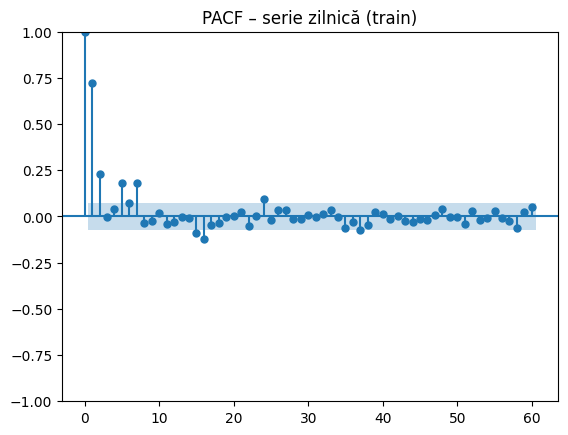

In [29]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10,4))
plot_acf(train, lags=60)
plt.title("ACF – serie zilnică (train)")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(train, lags=60, method="ywm")
plt.title("PACF – serie zilnică (train)")
plt.show()


## STL

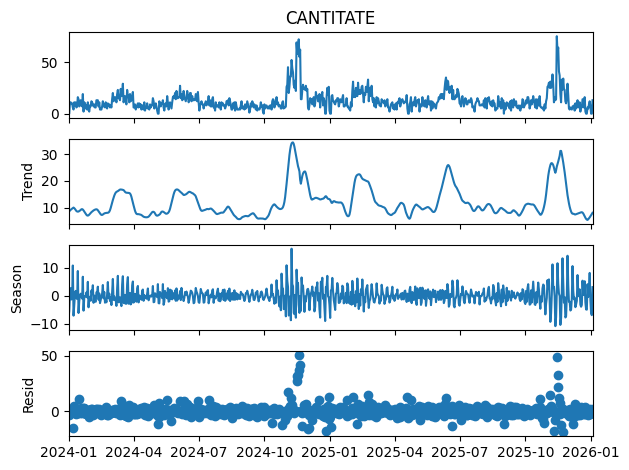

In [30]:
import pandas as pd
from statsmodels.tsa.seasonal import STL

# lucrăm pe o copie și pe o serie numerică, ca să nu afectăm restul celulelor
df_stl = df.copy()
df_stl["DATA"] = pd.to_datetime(df_stl["DATA"])

stl_series = (
    df_stl
    .sort_values("DATA")
    .set_index("DATA")["CANTITATE"]
    .astype(float)
    .asfreq("D")
)

# completăm lipsurile pentru a avea periodicitate constantă
stl_series = stl_series.interpolate("time").fillna(0)

stl = STL(stl_series, period=7, robust=True)
res = stl.fit()

res.plot()
plt.show()


## SARIMA

In [31]:
# pip install pmdarima  (dacă nu e instalat)
from pmdarima import auto_arima

sarima_weekly = auto_arima(
    train,
    seasonal=True,
    m=7,                 # sezonalitate săptămânală
    d=None, D=None,      # lasă auto_arima să aleagă diferențierea
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print("Model:", sarima_weekly.order, sarima_weekly.seasonal_order)


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=4564.828, Time=1.01 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=5149.825, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=4590.727, Time=0.18 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=4770.998, Time=0.24 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=5877.932, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=4571.897, Time=0.68 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=4566.861, Time=0.90 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=4566.804, Time=1.51 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=4566.800, Time=2.40 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=4597.261, Time=0.33 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=4567.777, Time=1.42 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=4565.452, Time=1.52 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=4568.781, Time=2.63 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=4563.925, Time=0.87 sec
 ARIMA(1,0,2)(0,0,1)[7] intercept

In [32]:
pred_weekly = pd.Series(
    sarima_weekly.predict(n_periods=len(test)),
    index=test.index
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(test, pred_weekly)
rmse = np.sqrt(mean_squared_error(test, pred_weekly))
r2 = r2_score(test, pred_weekly)

print("SARIMA weekly | MAE:", mae, "RMSE:", rmse, "R2:", r2)


SARIMA weekly | MAE: 5.308745176118525 RMSE: 6.532604883342901 R2: -1.3080003548878052


## SARIMA ( DF MONTHLY )

In [33]:
df_monthly = df_art.resample("MS").sum().asfreq("MS")  # ?nceput de lun?; sum? cantit??i pe lun?
df_monthly = df_monthly.fillna(0).astype(float)

forecast_horizon_monthly = 3
if forecast_horizon_monthly >= len(df_monthly):
    raise ValueError("forecast_horizon_monthly must be smaller than the monthly series length")

split_idx_m = len(df_monthly) - forecast_horizon_monthly
train_m = df_monthly.iloc[:split_idx_m]
test_m  = df_monthly.iloc[split_idx_m:]


In [34]:
len(train_m) // 2

11

<Figure size 1000x400 with 0 Axes>

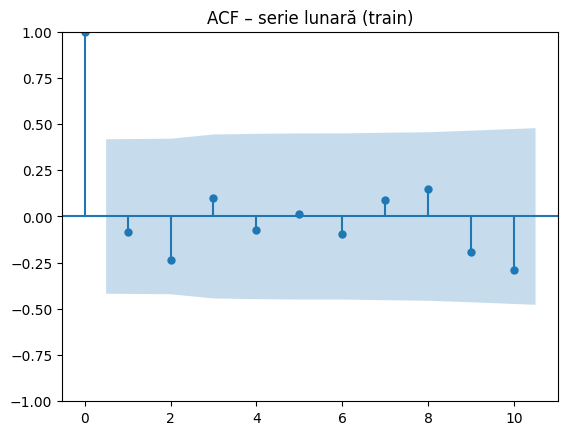

<Figure size 1000x400 with 0 Axes>

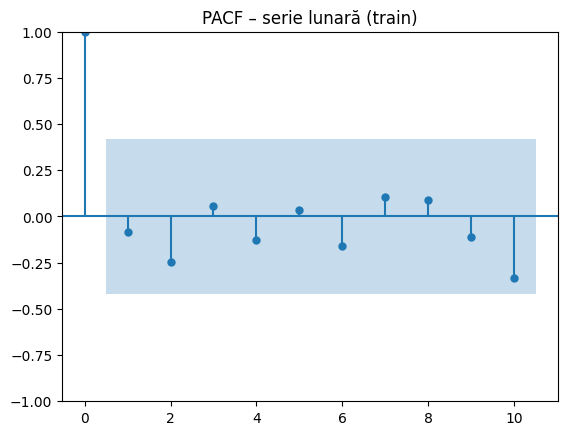

In [35]:
plt.figure(figsize=(10,4))
plot_acf(train_m, lags=10)
plt.title("ACF – serie lunară (train)")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(train_m, lags=10, method="ywm")
plt.title("PACF – serie lunară (train)")
plt.show()


# lags - pe ce timeline modelam : 10 luni in acest caz

In [36]:
sarima_monthly = auto_arima(
    train_m,
    seasonal=True,
    m=12,              # sezonalitate anuală pe lună
    d=None, D=None,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print("Model:", sarima_monthly.order, sarima_monthly.seasonal_order)

pred_m = sarima_monthly.arima_res_.get_forecast(steps=len(test_m)).predicted_mean
pred_m = pd.Series(pred_m, index=test_m.index).fillna(0)

mae_m = mean_absolute_error(test_m, pred_m)
rmse_m = np.sqrt(mean_squared_error(test_m, pred_m))
r2_m = r2_score(test_m, pred_m)

print("SARIMA monthly | MAE:", mae_m, "RMSE:", rmse_m, "R2:", r2_m)


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\pmdarima\arima\utils.py:117: UserWarning:

Appropriate D value may not have been reached; length of seasonally-differenced array (10) is shorter than m (12). Using D=1



Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=1506733667.825, Time=0.28 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=129.758, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=129.838, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=131.706, Time=0.18 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=128.723, Time=0.04 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=130.002, Time=0.11 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=127.331, Time=0.09 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=135.593, Time=0.57 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Ti

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:1901: RuntimeWarning:

divide by zero encountered in reciprocal

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning:

invalid value encountered in reciprocal

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\pmdarima\arima\_auto_solvers.py:40: RuntimeWarning:

invalid value encountered in divide



 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=12.000, Time=0.20 sec


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:1901: RuntimeWarning:

divide by zero encountered in reciprocal

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning:

invalid value encountered in reciprocal

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\pmdarima\arima\_auto_solvers.py:40: RuntimeWarning:

invalid value encountered in divide



 ARIMA(1,0,2)(1,1,1)[12] intercept   : AIC=14.000, Time=0.24 sec
 ARIMA(0,0,2)(0,1,0)[12] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(2,0,2)(0,1,0)[12] intercept   : AIC=1506730659.449, Time=0.09 sec
 ARIMA(1,0,3)(0,1,0)[12] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(0,0,3)(0,1,0)[12] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(2,0,3)(0,1,0)[12] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(1,0,2)(0,1,0)[12]             : AIC=inf, Time=0.13 sec

Best model:  ARIMA(1,0,2)(0,1,0)[12] intercept
Total fit time: 6.250 seconds
Model: (1, 0, 2) (0, 1, 0, 12)
SARIMA monthly | MAE: 281.05380276334677 RMSE: 284.762461728786 R2: 0.34956325745700667


In [37]:
import plotly.express as px

df_plot = pd.DataFrame({
    "DATA": test.index,
    "Actual": test.values,
    "Pred_SARIMA_weekly": pred_weekly.values
})

df_long = df_plot.melt("DATA", var_name="Serie", value_name="Cantitate")

fig = px.line(df_long, x="DATA", y="Cantitate", color="Serie",
              title="SARIMA (m=7) – Actual vs Predicted (test)")
fig.update_layout(hovermode="x unified", xaxis_title="Data", yaxis_title="Cantitate")
fig.update_xaxes(rangeslider_visible=True)
fig.show()


In [38]:
df_plot_m = pd.DataFrame({
    "DATA": test_m.index,
    "Actual": test_m.values,
    "Pred_SARIMA_monthly": pred_m.values
})

df_long_m = df_plot_m.melt("DATA", var_name="Serie", value_name="Cantitate")

fig = px.line(df_long_m, x="DATA", y="Cantitate", color="Serie",
              title="SARIMA (m=12) – Actual vs Predicted (test, lunar)")
fig.update_layout(hovermode="x unified", xaxis_title="Luna", yaxis_title="Cantitate (sumă lunară)")
fig.update_xaxes(rangeslider_visible=True)
fig.show()


In [39]:
import pandas as pd
import numpy as np

df_smx = df.copy()
df_smx["DATA"] = pd.to_datetime(df_smx["DATA"])
df_smx = df_smx.sort_values("DATA")


# selectăm coloanele
cols = ["DATA", "CANTITATE", "RATA_DISCOUNT", "STOC_INITIAL"]
df_smx = df_smx[cols]

# agregare zilnică
daily = df_smx.groupby("DATA", as_index=False).agg({
    "CANTITATE": "sum",
    "RATA_DISCOUNT": "mean",
    "STOC_INITIAL": "mean"
})

# completare zile lipsă
daily = daily.set_index("DATA").asfreq("D").fillna(0).reset_index()

daily.head()


,DATA,CANTITATE,RATA_DISCOUNT,STOC_INITIAL
0,2024-01-01,0,0.0,278.0
1,2024-01-02,0,0.0,278.0
2,2024-01-03,11,0.0,278.0
3,2024-01-04,11,0.0,267.0
4,2024-01-05,10,0.0,376.0


In [40]:
split_idx = len(daily) - forecast_horizon_daily

train = daily.iloc[:split_idx].copy()
test  = daily.iloc[split_idx:].copy()

y_train = train["CANTITATE"]
y_test  = test["CANTITATE"]

X_train = train[["RATA_DISCOUNT", "STOC_INITIAL"]]
X_test  = test[["RATA_DISCOUNT", "STOC_INITIAL"]]


In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 0),          # ARIMA(1,0,0)
    seasonal_order=(0, 0, 0, 0),  # fără sezonalitate
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:              CANTITATE   No. Observations:                  704
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -2269.536
Date:                Wed, 21 Jan 2026   AIC                           4547.072
Time:                        23:44:13   BIC                           4565.294
Sample:                             0   HQIC                          4554.115
                                - 704                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
RATA_DISCOUNT    32.3059      2.265     14.263      0.000      27.867      36.745
STOC_INITIAL      0.0267      0.002     16.590      0.000       0.024       0.030
ar.L1             0.5303      0.018     

In [42]:
pred_sarimax = model_fit.forecast(
    steps=len(test),
    exog=X_test
)

pred_sarimax = np.maximum(pred_sarimax, 0)  # retail safety


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, pred_sarimax)
rmse = np.sqrt(mean_squared_error(y_test, pred_sarimax))
r2 = r2_score(y_test, pred_sarimax)

mae, rmse, r2


(27.85310242493737, np.float64(29.869085712663132), -47.251069838313505)

In [44]:
import plotly.express as px

df_plot = pd.DataFrame({
    "DATA": test["DATA"],
    "Actual": y_test.values,
    "Pred_SARIMAX": pred_sarimax.values
})

df_long = df_plot.melt("DATA", var_name="Serie", value_name="Cantitate")

fig = px.line(
    df_long,3
    x="DATA",
    y="Cantitate",
    color="Serie",
    title="SARIMAX – Actual vs Predicted (test)"
)

fig.update_layout(
    hovermode="x unified",
    xaxis_title="Data",
    yaxis_title="Cantitate"
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (150545899.py, line 12)